# MARIDA Semantic Segmentation



In [1]:
from pathlib import Path
import random
import os
import numpy as np
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
BATCH_SIZE = 5
LEARNING_RATE = 2e-4
NUM_EPOCHS = 45
NUM_BANDS = 11
NUM_CLASSES = 11
IGNORE_INDEX = -1
NUM_WORKERS = 2
CLASS_WEIGHT_C = 1.02
BEST_MODEL_PATH = Path("/kaggle/working/marida_unet_best.pt")


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [2]:
input_dir = Path("/kaggle/input/MARIDA Dataset/MARIDA")
print(input_dir)

/kaggle/input/MARIDA Dataset/MARIDA


## Load the dataset

In [3]:
input_dir = Path("/kaggle/input/")
patch_candidates = [
    path
    for path in input_dir.rglob("patches")
    if path.is_dir()
]

if not patch_candidates:
    raise FileNotFoundError(
        "No MARIDA patches folder was found "
        "under /kaggle/input"
    )

patches_dir = patch_candidates[0]
marida_dir = patches_dir.parent
splits_dir = marida_dir / "splits"

split_paths = {
    "train": splits_dir / "train_X.txt",
    "val": splits_dir / "val_X.txt",
    "test": splits_dir / "test_X.txt",
}

for split_name, split_path in split_paths.items():
    if not split_path.exists():
        raise FileNotFoundError(
            f"Missing {split_name} split file: "
            f"{split_path}"
        )

print("MARIDA directory:", marida_dir)
print("Patches directory:", patches_dir)

MARIDA directory: /kaggle/input/datasets/hemalmarepalli/marida-dataset/MARIDA
Patches directory: /kaggle/input/datasets/hemalmarepalli/marida-dataset/MARIDA/patches


In [4]:
class_names = [
    "Marine Debris",
    "Dense Sargassum",
    "Sparse Sargassum",
    "Natural Organic Material",
    "Ship",
    "Clouds",
    "Marine Water",
    "Sediment-Laden Water",
    "Foam",
    "Turbid Water",
    "Shallow Water",
]

band_means = np.array([
    0.051976, 0.047840, 0.040568, 0.031636, 0.029726,
    0.034574, 0.038750, 0.034364, 0.039211, 0.023581,
    0.015888,
], dtype=np.float32)

band_stds = np.array([
    0.047259, 0.047438, 0.046990, 0.049674, 0.049468,
    0.064584, 0.075949, 0.071202, 0.082511, 0.051115,
    0.035244,
], dtype=np.float32)


def read_split(path):
    with open(path, "r") as file:
        return [line.strip() for line in file if line.strip()]


def get_patch_paths(patch_id):
    scene = "_".join(patch_id.split("_")[:-1])
    folder = patches_dir / f"S2_{scene}"
    return folder / f"S2_{patch_id}.tif", folder / f"S2_{patch_id}_cl.tif"


def prepare_mask(mask):
    mask = mask.astype(np.int64).copy()
    mask[np.isin(mask, [12, 13, 14, 15])] = 7
    return mask - 1


def augment_pair(image, mask):
    rotation = random.randrange(4)
    if rotation:
        image = np.rot90(image, rotation, axes=(1, 2))
        mask = np.rot90(mask, rotation, axes=(0, 1))

    if random.random() < 0.5:
        image = np.flip(image, axis=2)
        mask = np.flip(mask, axis=1)

    return np.ascontiguousarray(image), np.ascontiguousarray(mask)


split_ids = {name: read_split(path) for name, path in split_paths.items()}
for name, ids in split_ids.items():
    print(f"{name.title()} patches: {len(ids)}")

Train patches: 694
Val patches: 328
Test patches: 359


In [5]:
class MaridaDataset(Dataset):
    def __init__(self, patch_ids, augment=False):
        self.patch_ids = patch_ids
        self.augment = augment
        self.means = band_means[:, None, None]
        self.stds = band_stds[:, None, None]

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, index):
        image_path, mask_path = get_patch_paths(self.patch_ids[index])

        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)

        with rasterio.open(mask_path) as src:
            mask = src.read(1)

        if image.shape[0] != NUM_BANDS:
            raise ValueError(f"{image_path.name} has {image.shape[0]} bands")

        image = np.where(np.isfinite(image), image, self.means)
        image = (image - self.means) / self.stds
        mask = prepare_mask(mask)

        if self.augment:
            image, mask = augment_pair(image, mask)

        return torch.from_numpy(image).float(), torch.from_numpy(mask).long()


def make_loader(dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


datasets = {
    "train": MaridaDataset(split_ids["train"], augment=True),
    "val": MaridaDataset(split_ids["val"]),
    "test": MaridaDataset(split_ids["test"]),
}

loaders = {
    "train": make_loader(datasets["train"], shuffle=True),
    "val": make_loader(datasets["val"], shuffle=False),
    "test": make_loader(datasets["test"], shuffle=False),
}

for name in datasets:
    print(f"{name.title()}: {len(datasets[name])} patches, {len(loaders[name])} batches")

Train: 694 patches, 139 batches
Val: 328 patches, 66 batches
Test: 359 patches, 72 batches


In [6]:
image, mask = datasets["train"][0]
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask values:", torch.unique(mask))

Image shape: torch.Size([11, 256, 256])
Mask shape: torch.Size([256, 256])
Mask values: tensor([-1,  4,  6])


## Class distribution and weights

In [6]:
def count_classes(patch_ids):
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    empty_patches = 0

    for patch_id in patch_ids:
        _, mask_path = get_patch_paths(patch_id)
        with rasterio.open(mask_path) as src:
            mask = prepare_mask(src.read(1))

        valid = mask != IGNORE_INDEX
        if not valid.any():
            empty_patches += 1
            continue

        counts += np.bincount(mask[valid], minlength=NUM_CLASSES)

    return counts, empty_patches


def print_distribution(name, counts):
    total = counts.sum()
    print()
    print(f"{name} class distribution")
    print("-" * 70)

    for index, class_name in enumerate(class_names):
        percentage = counts[index] / total * 100 if total else 0
        print(f"{index:2d}  {class_name:<28} {counts[index]:>10,} pixels  {percentage:>8.4f}%")

    print("-" * 70)
    print("Total labeled pixels:", f"{total:,}")


class_counts = {}
empty_patches = {}

for name, ids in split_ids.items():
    class_counts[name], empty_patches[name] = count_classes(ids)
    print_distribution(name.title(), class_counts[name])
    print("Empty patches:", empty_patches[name])


Train class distribution
----------------------------------------------------------------------
 0  Marine Debris                     1,943 pixels    0.4525%
 1  Dense Sargassum                     870 pixels    0.2026%
 2  Sparse Sargassum                  1,091 pixels    0.2541%
 3  Natural Organic Material            723 pixels    0.1684%
 4  Ship                              3,289 pixels    0.7659%
 5  Clouds                           65,295 pixels   15.2057%
 6  Marine Water                    100,725 pixels   23.4565%
 7  Sediment-Laden Water            154,335 pixels   35.9410%
 8  Foam                                469 pixels    0.1092%
 9  Turbid Water                     86,820 pixels   20.2183%
10  Shallow Water                    13,852 pixels    3.2258%
----------------------------------------------------------------------
Total labeled pixels: 429,412
Empty patches: 0

Val class distribution
----------------------------------------------------------------------
 0  Mari

In [8]:
def calculate_class_weights(counts, c=CLASS_WEIGHT_C):
    frequencies = counts.astype(np.float64) / counts.sum()
    weights = 1.0 / np.log(c + frequencies)
    return torch.tensor(weights, dtype=torch.float32)


class_weights = calculate_class_weights(class_counts["train"])

for index, class_name in enumerate(class_names):
    print(f"{index:2d}  {class_name:<28} {class_weights[index].item():.4f}")

 0  Marine Debris                41.2730
 1  Dense Sargassum              45.8990
 2  Sparse Sargassum             44.8624
 3  Natural Organic Material     46.6158
 4  Ship                         36.6519
 5  Clouds                       6.2988
 6  Marine Water                 4.4094
 7  Sediment-Laden Water         3.1089
 8  Foam                         47.9092
 9  Turbid Water                 4.9841
10  Shallow Water                19.6316


In [7]:
class_weights = torch.tensor([
    20.0000,  # Marine Debris - originally 41. ...
    45.8990,  # Dense Sargassum
    44.8624,  # Sparse Sargassum
    46.6158,  # Natural Organic Material
    36.6519,  # Ship
    6.2988,   # Clouds
    4.4094,   # Marine Water
    3.1089,   # Sediment-Laden Water
    47.9092,  # Foam
    4.9841,   # Turbid Water
    19.6316,  # Shallow Water
], dtype=torch.float32)

for class_index, class_name in enumerate(
    class_names
):
    print(
        f"{class_index:2d} "
        f"{class_name:<28} "
        f"{class_weights[class_index].item():.4f}"
    )


 0 Marine Debris                20.0000
 1 Dense Sargassum              45.8990
 2 Sparse Sargassum             44.8624
 3 Natural Organic Material     46.6158
 4 Ship                         36.6519
 5 Clouds                       6.2988
 6 Marine Water                 4.4094
 7 Sediment-Laden Water         3.1089
 8 Foam                         47.9092
 9 Turbid Water                 4.9841
10 Shallow Water                19.6316


## U-Net

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.layers(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)

        # Normal skip connection without attention
        x = torch.cat([x, skip], dim=1)

        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=NUM_BANDS, num_classes=NUM_CLASSES):
        super().__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        #Encoder
        self.encoder1 = DoubleConv(in_channels, 16)
        self.encoder2 = DoubleConv(16, 32)
        self.encoder3 = DoubleConv(32, 64)
        self.encoder4 = DoubleConv(64, 128)

        #Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        #decoder
        self.decoder4 = UpBlock(256, 128, 128)
        self.decoder3 = UpBlock(128, 64, 64)
        self.decoder2 = UpBlock(64, 32, 32)
        self.decoder1 = UpBlock(32, 16, 16)

        #pixel classification
        self.output_layer = nn.Conv2d(
            16,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        #encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))

        #Bottleneck
        x = self.bottleneck(self.pool(enc4))

        #Decoder with normal skip connections
        x = self.decoder4(x, enc4)
        x = self.decoder3(x, enc3)
        x = self.decoder2(x, enc2)
        x = self.decoder1(x, enc1)

        return self.output_layer(x)

In [9]:
def create_model():
    model = UNet()
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        print("Using", torch.cuda.device_count(), "GPUs")
    return model.to(device)


model = create_model()
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), ignore_index=IGNORE_INDEX)
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[40], gamma=0.1)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print("Model parameters:", f"{parameter_count:,}")
print("Learning rate:", LEARNING_RATE)

Using 2 GPUs
Model parameters: 1,942,427
Learning rate: 0.0002


In [12]:
image, mask = datasets["train"][0]

with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))

print("Input shape:", image.unsqueeze(0).shape)
print("Output shape:", output.shape)
print("Mask shape:", mask.shape)
print("Output finite:", torch.isfinite(output).all().item())

Input shape: torch.Size([1, 11, 256, 256])
Output shape: torch.Size([1, 11, 256, 256])
Mask shape: torch.Size([256, 256])
Output finite: True


## Training and evaluation functions

In [10]:
def metrics_from_confusion_matrix(confusion_matrix):
    true_positive = confusion_matrix.diag().float()
    actual_count = confusion_matrix.sum(dim=1).float()
    predicted_count = confusion_matrix.sum(dim=0).float()
    union = actual_count + predicted_count - true_positive

    iou = torch.zeros(NUM_CLASSES)
    precision = torch.zeros(NUM_CLASSES)
    recall = torch.zeros(NUM_CLASSES)
    f1 = torch.zeros(NUM_CLASSES)

    iou[union > 0] = true_positive[union > 0] / union[union > 0]
    precision[predicted_count > 0] = true_positive[predicted_count > 0] / predicted_count[predicted_count > 0]
    recall[actual_count > 0] = true_positive[actual_count > 0] / actual_count[actual_count > 0]

    valid_f1 = precision + recall > 0
    f1[valid_f1] = 2 * precision[valid_f1] * recall[valid_f1] / (precision[valid_f1] + recall[valid_f1])

    present = actual_count > 0
    mean_iou = iou[present].mean().item() if present.any() else 0.0
    macro_f1 = f1[present].mean().item() if present.any() else 0.0
    pixel_accuracy = (true_positive.sum() / confusion_matrix.sum().clamp(min=1)).item()

    return {
        "mean_iou": mean_iou,
        "macro_f1": macro_f1,
        "pixel_accuracy": pixel_accuracy,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


@torch.no_grad()
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    used_batches = 0
    confusion_matrix = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        valid = masks != IGNORE_INDEX

        if not valid.any():
            continue

        with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
            outputs = model(images)
            loss = criterion(outputs, masks)

        if not torch.isfinite(loss):
            continue

        total_loss += loss.item()
        used_batches += 1

        predictions = outputs.argmax(dim=1)
        positions = masks[valid] * NUM_CLASSES + predictions[valid]
        confusion_matrix += torch.bincount(
            positions,
            minlength=NUM_CLASSES * NUM_CLASSES,
        ).reshape(NUM_CLASSES, NUM_CLASSES).cpu()

    results = metrics_from_confusion_matrix(confusion_matrix)
    results.update({
        "loss": total_loss / max(used_batches, 1),
        "confusion_matrix": confusion_matrix,
        "used_batches": used_batches,
    })
    return results

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    used_batches = 0
    skipped_batches = 0

    for batch_number, (images, masks) in enumerate(loader, start=1):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if not (masks != IGNORE_INDEX).any():
            skipped_batches += 1
            continue

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
            outputs = model(images)
            loss = criterion(outputs, masks)

        if not torch.isfinite(loss):
            skipped_batches += 1
            continue

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        used_batches += 1

    return total_loss / max(used_batches, 1), used_batches, skipped_batches


def save_model(model, path):
    state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    torch.save(state, path)


def load_model(model, path):
    target = model.module if isinstance(model, nn.DataParallel) else model
    target.load_state_dict(torch.load(path, map_location=device))


def train_model(model, train_loader, val_loader, optimizer, criterion, scaler, epochs, model_path, scheduler=None):
    best_val_loss = float("inf")
    history = {"train_loss": [], "val_loss": [], "mean_iou": [], "macro_f1": [], "pixel_accuracy": []}

    for epoch in range(1, epochs + 1):
        train_loss, used_batches, skipped_batches = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler
        )
        results = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(results["loss"])
        history["mean_iou"].append(results["mean_iou"])
        history["macro_f1"].append(results["macro_f1"])
        history["pixel_accuracy"].append(results["pixel_accuracy"])

        print()
        print(f"Epoch {epoch}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Validation Loss: {results['loss']:.4f}")
        print(f"Mean IoU: {results['mean_iou']:.4f}")
        print(f"Macro F1: {results['macro_f1']:.4f}")
        print(f"Pixel Accuracy: {results['pixel_accuracy']:.4f}")
        print(f"Training Batches: {used_batches} used, {skipped_batches} skipped")

        if results["loss"] < best_val_loss:
            best_val_loss = results["loss"]
            save_model(model, model_path)
            print("Saved best model")

        if scheduler is not None:
            scheduler.step()

    print()
    print("Training complete")
    print("Best validation loss:", best_val_loss)
    print("Best model:", model_path)
    return history

## Train the model

In [15]:
history = train_model(
    model=model,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    optimizer=optimizer,
    criterion=criterion,
    scaler=scaler,
    epochs=NUM_EPOCHS,
    model_path=BEST_MODEL_PATH,
    scheduler=scheduler,
)


Epoch 1/45
Train Loss: 2.2624
Validation Loss: 2.1779
Mean IoU: 0.0108
Macro F1: 0.0195
Pixel Accuracy: 0.0841
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 2/45
Train Loss: 2.0536
Validation Loss: 2.0550
Mean IoU: 0.0445
Macro F1: 0.0706
Pixel Accuracy: 0.1892
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 3/45
Train Loss: 1.8498
Validation Loss: 1.8899
Mean IoU: 0.1093
Macro F1: 0.1418
Pixel Accuracy: 0.1931
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 4/45
Train Loss: 1.7032
Validation Loss: 1.7667
Mean IoU: 0.1291
Macro F1: 0.1725
Pixel Accuracy: 0.3033
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 5/45
Train Loss: 1.6650
Validation Loss: 1.7077
Mean IoU: 0.1071
Macro F1: 0.1327
Pixel Accuracy: 0.1938
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 6/45
Train Loss: 1.5487
Validation Loss: 1.6607
Mean IoU: 0.1045
Macro F1: 0.1297
Pixel Accuracy: 0.1902
Training Batches: 139 used, 0 skipped
Saved best mode

## Final validation results

In [12]:
def print_results(results):
    print("Test loss:", f"{results['loss']:.4f}")
    print("Mean IoU:", f"{results['mean_iou']:.4f}")
    print("Macro F1:", f"{results['macro_f1']:.4f}")
    print("Pixel accuracy:", f"{results['pixel_accuracy']:.4f}")

    print()
    print("Per-class results")
    print("-" * 90)
    for index, class_name in enumerate(class_names):
        print(
            f"{index:2d} {class_name:<28} "
            f"IoU: {results['iou'][index].item():.4f}  "
            f"Precision: {results['precision'][index].item():.4f}  "
            f"Recall: {results['recall'][index].item():.4f}  "
            f"F1: {results['f1'][index].item():.4f}"
        )

    prediction_counts = results["confusion_matrix"].sum(dim=0)
    target_counts = results["confusion_matrix"].sum(dim=1)

    print()
    print("Prediction distribution")
    print("-" * 65)
    for index, class_name in enumerate(class_names):
        predicted_percent = prediction_counts[index].float() / prediction_counts.sum().clamp(min=1) * 100
        target_percent = target_counts[index].float() / target_counts.sum().clamp(min=1) * 100
        print(f"{class_name:<28} Predicted: {predicted_percent.item():7.3f}%  Target: {target_percent.item():7.3f}%")

In [17]:
load_model(model, BEST_MODEL_PATH)
test_results = evaluate_model(model, loaders["test"], criterion)
print_results(test_results)

Test loss: 0.6371
Mean IoU: 0.5842
Macro F1: 0.7002
Pixel accuracy: 0.9297

Per-class results
------------------------------------------------------------------------------------------
 0 Marine Debris                IoU: 0.1787  Precision: 0.2636  Recall: 0.3570  F1: 0.3032
 1 Dense Sargassum              IoU: 0.6453  Precision: 0.6544  Recall: 0.9789  F1: 0.7844
 2 Sparse Sargassum             IoU: 0.4916  Precision: 0.7971  Recall: 0.5619  F1: 0.6591
 3 Natural Organic Material     IoU: 0.1250  Precision: 0.3478  Recall: 0.1633  F1: 0.2222
 4 Ship                         IoU: 0.5821  Precision: 0.6297  Recall: 0.8850  F1: 0.7358
 5 Clouds                       IoU: 0.7749  Precision: 0.9871  Recall: 0.7828  F1: 0.8732
 6 Marine Water                 IoU: 0.7184  Precision: 0.7790  Recall: 0.9023  F1: 0.8361
 7 Sediment-Laden Water         IoU: 0.9975  Precision: 0.9982  Recall: 0.9993  F1: 0.9987
 8 Foam                         IoU: 0.5885  Precision: 0.6781  Recall: 0.8165  F1: 0.7

In [13]:
import matplotlib.pyplot as plt


def plot_loss(history):
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]

    epochs = range(1, len(train_loss) + 1)

    best_epoch = val_loss.index(min(val_loss)) + 1
    best_val_loss = min(val_loss)

    plt.figure(figsize=(10, 5))

    plt.plot(epochs, train_loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")

    plt.scatter(
        best_epoch,
        best_val_loss,
        label=f"Lowest Validation Loss: Epoch {best_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Lowest validation loss: {best_val_loss:.4f}")
    print(f"Best epoch by validation loss: {best_epoch}")

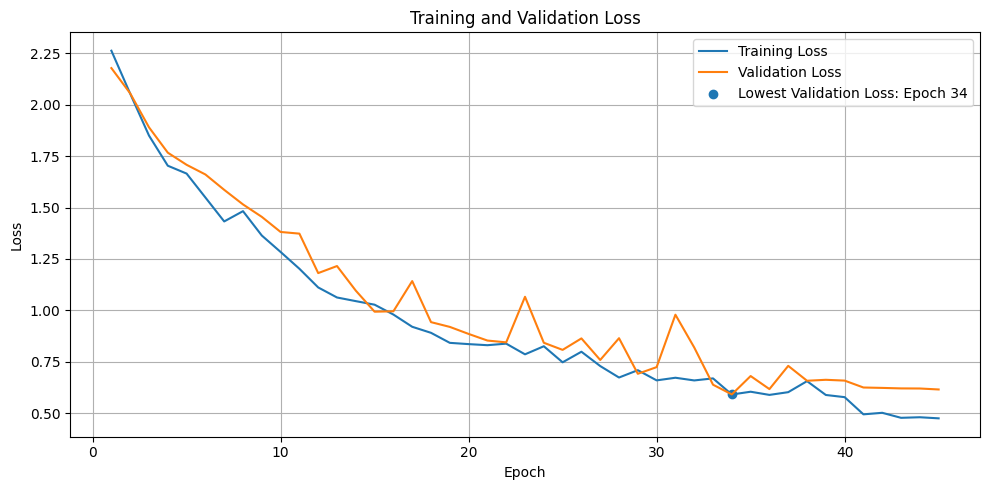

Lowest validation loss: 0.5912
Best epoch by validation loss: 34


In [19]:
plot_loss(history)

In [20]:
def plot_metrics(history):
    epochs = range(1, len(history["mean_iou"]) + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(
        epochs,
        history["mean_iou"],
        label="Validation Mean IoU"
    )

    plt.plot(
        epochs,
        history["macro_f1"],
        label="Validation Macro F1"
    )

    plt.plot(
        epochs,
        history["pixel_accuracy"],
        label="Validation Pixel Accuracy"
    )

    best_iou_epoch = history["mean_iou"].index(
        max(history["mean_iou"])
    ) + 1

    best_f1_epoch = history["macro_f1"].index(
        max(history["macro_f1"])
    ) + 1

    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Validation Metrics")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(
        f"Highest Mean IoU: "
        f"{max(history['mean_iou']):.4f} "
        f"at epoch {best_iou_epoch}"
    )

    print(
        f"Highest Macro F1: "
        f"{max(history['macro_f1']):.4f} "
        f"at epoch {best_f1_epoch}"
    )

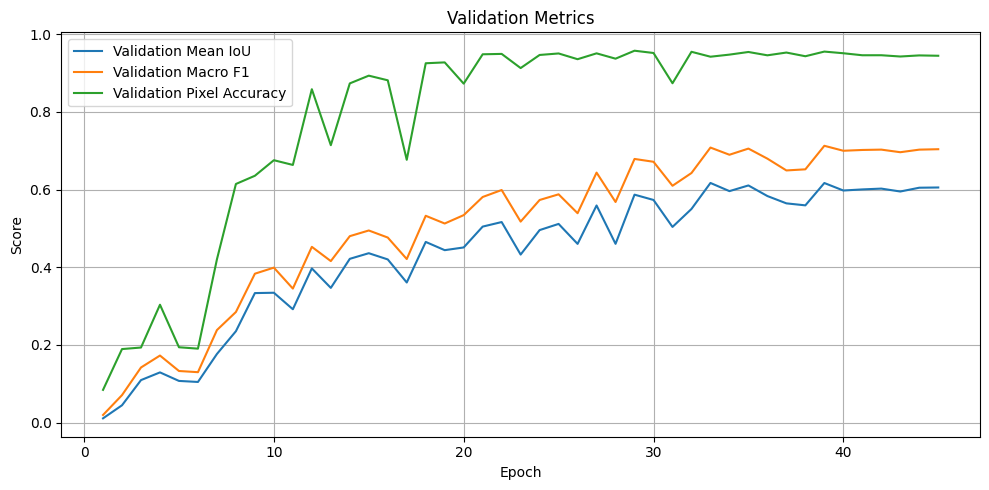

Highest Mean IoU: 0.6169 at epoch 33
Highest Macro F1: 0.7126 at epoch 39


In [21]:
plot_metrics(history)

In [22]:
plain_model = model
plain_history = history
plain_test_results = test_results
PLAIN_MODEL_PATH = BEST_MODEL_PATH

print("Plain U-Net results preserved.")
print("Plain U-Net checkpoint:", PLAIN_MODEL_PATH)

Plain U-Net results preserved.
Plain U-Net checkpoint: /kaggle/working/marida_unet_best.pt


In [14]:
class AttentionGate(nn.Module):
    def __init__(self, gate_channels, skip_channels, inter_channels):
        super().__init__()

        # Transform decoder and encoder features to the same channel size
        self.gate_conv = nn.Conv2d(
            gate_channels,
            inter_channels,
            kernel_size=1
        )

        self.skip_conv = nn.Conv2d(
            skip_channels,
            inter_channels,
            kernel_size=1
        )

        # Produce one attention weight for each spatial position
        self.attention = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(inter_channels, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, gate, skip):
        gate_features = self.gate_conv(gate)
        skip_features = self.skip_conv(skip)

        attention_weights = self.attention(
            gate_features + skip_features
        )

        return skip * attention_weights


class AttentionUpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionGate(
            gate_channels=out_channels,
            skip_channels=skip_channels,
            inter_channels=max(out_channels // 2, 1)
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)

        #Filter the encoder skip connection before concatenation
        skip = self.attention(
            gate=x,
            skip=skip
        )

        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class AttentionUNet(nn.Module):
    def __init__(
        self,
        in_channels=NUM_BANDS,
        num_classes=NUM_CLASSES
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        #Encoder
        self.encoder1 = DoubleConv(in_channels, 16)
        self.encoder2 = DoubleConv(16, 32)
        self.encoder3 = DoubleConv(32, 64)
        self.encoder4 = DoubleConv(64, 128)

        #Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        #Decoder with attention-filtered skip connections
        self.decoder4 = AttentionUpBlock(256, 128, 128)
        self.decoder3 = AttentionUpBlock(128, 64, 64)
        self.decoder2 = AttentionUpBlock(64, 32, 32)
        self.decoder1 = AttentionUpBlock(32, 16, 16)

        self.output_layer = nn.Conv2d(
            16,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))

        x = self.bottleneck(self.pool(enc4))

        x = self.decoder4(x, enc4)
        x = self.decoder3(x, enc3)
        x = self.decoder2(x, enc2)
        x = self.decoder1(x, enc1)

        return self.output_layer(x)

In [24]:
ATTENTION_MODEL_PATH = Path(
    "/kaggle/working/marida_attention_unet_best.pt"
)

#reset randomness so both modles begin from the same seed
set_seed(SEED)

attention_model = AttentionUNet()

if torch.cuda.device_count() > 1:
    attention_model = nn.DataParallel(attention_model)
    print("Using", torch.cuda.device_count(), "GPUs")

attention_model = attention_model.to(device)

attention_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    ignore_index=IGNORE_INDEX
)

attention_optimizer = torch.optim.Adam(
    attention_model.parameters(),
    lr=LEARNING_RATE
)

attention_scheduler = torch.optim.lr_scheduler.MultiStepLR(
    attention_optimizer,
    milestones=[40],
    gamma=0.1
)

attention_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=device.type == "cuda"
)

attention_parameter_count = sum(
    parameter.numel()
    for parameter in attention_model.parameters()
)

plain_parameter_count = sum(
    parameter.numel()
    for parameter in plain_model.parameters()
)

print("Plain U-Net parameters:", f"{plain_parameter_count:,}")
print("Attention U-Net parameters:", f"{attention_parameter_count:,}")
print("Learning rate:", LEARNING_RATE)

Using 2 GPUs
Plain U-Net parameters: 1,942,427
Attention U-Net parameters: 1,964,551
Learning rate: 0.0002


In [25]:
#Confirm that the new model accepts an 11-band image
#and returns one score map for each of the 11 classes
image, mask = datasets["train"][0]

attention_model.eval()

with torch.no_grad():
    output = attention_model(
        image.unsqueeze(0).to(device)
    )

print("Input shape:", image.unsqueeze(0).shape)
print("Output shape:", output.shape)
print("Mask shape:", mask.shape)
print("Output finite:", torch.isfinite(output).all().item())

Input shape: torch.Size([1, 11, 256, 256])
Output shape: torch.Size([1, 11, 256, 256])
Mask shape: torch.Size([256, 256])
Output finite: True


In [26]:
attention_history = train_model(
    model=attention_model,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    optimizer=attention_optimizer,
    criterion=attention_criterion,
    scaler=attention_scaler,
    epochs=NUM_EPOCHS,
    model_path=ATTENTION_MODEL_PATH,
    scheduler=attention_scheduler
)


Epoch 1/45
Train Loss: 2.3842
Validation Loss: 2.1422
Mean IoU: 0.0107
Macro F1: 0.0191
Pixel Accuracy: 0.0840
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 2/45
Train Loss: 2.0514
Validation Loss: 1.9640
Mean IoU: 0.0422
Macro F1: 0.0660
Pixel Accuracy: 0.1874
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 3/45
Train Loss: 1.8749
Validation Loss: 1.8302
Mean IoU: 0.0432
Macro F1: 0.0683
Pixel Accuracy: 0.1888
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 4/45
Train Loss: 1.7434
Validation Loss: 1.7495
Mean IoU: 0.2066
Macro F1: 0.2522
Pixel Accuracy: 0.7547
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 5/45
Train Loss: 1.6320
Validation Loss: 1.6860
Mean IoU: 0.2279
Macro F1: 0.2687
Pixel Accuracy: 0.7733
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 6/45
Train Loss: 1.6037
Validation Loss: 1.5933
Mean IoU: 0.2825
Macro F1: 0.3402
Pixel Accuracy: 0.8559
Training Batches: 139 used, 0 skipped
Saved best mode

In [27]:
load_model(
    attention_model,
    ATTENTION_MODEL_PATH
)

attention_test_results = evaluate_model(
    attention_model,
    loaders["test"],
    attention_criterion
)

print_results(attention_test_results)

Test loss: 0.6483
Mean IoU: 0.5869
Macro F1: 0.7014
Pixel accuracy: 0.9308

Per-class results
------------------------------------------------------------------------------------------
 0 Marine Debris                IoU: 0.2428  Precision: 0.2901  Recall: 0.5984  F1: 0.3907
 1 Dense Sargassum              IoU: 0.7200  Precision: 0.7320  Recall: 0.9776  F1: 0.8372
 2 Sparse Sargassum             IoU: 0.5857  Precision: 0.8529  Recall: 0.6515  F1: 0.7387
 3 Natural Organic Material     IoU: 0.2347  Precision: 0.3194  Recall: 0.4694  F1: 0.3802
 4 Ship                         IoU: 0.6009  Precision: 0.6575  Recall: 0.8748  F1: 0.7507
 5 Clouds                       IoU: 0.7968  Precision: 0.9861  Recall: 0.8058  F1: 0.8869
 6 Marine Water                 IoU: 0.7515  Precision: 0.8255  Recall: 0.8935  F1: 0.8582
 7 Sediment-Laden Water         IoU: 0.9955  Precision: 0.9986  Recall: 0.9969  F1: 0.9978
 8 Foam                         IoU: 0.4151  Precision: 0.4603  Recall: 0.8088  F1: 0.5

In [28]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Plain U-Net",
        "Parameters": plain_parameter_count,
        "Test Loss": plain_test_results["loss"],
        "Mean IoU": plain_test_results["mean_iou"],
        "Macro F1": plain_test_results["macro_f1"],
        "Pixel Accuracy": plain_test_results["pixel_accuracy"],
        "Marine Debris IoU": plain_test_results["iou"][0].item(),
        "Marine Debris F1": plain_test_results["f1"][0].item(),
        "Marine Debris Precision": plain_test_results["precision"][0].item(),
        "Marine Debris Recall": plain_test_results["recall"][0].item()
    },
    {
        "Model": "Attention U-Net",
        "Parameters": attention_parameter_count,
        "Test Loss": attention_test_results["loss"],
        "Mean IoU": attention_test_results["mean_iou"],
        "Macro F1": attention_test_results["macro_f1"],
        "Pixel Accuracy": attention_test_results["pixel_accuracy"],
        "Marine Debris IoU": attention_test_results["iou"][0].item(),
        "Marine Debris F1": attention_test_results["f1"][0].item(),
        "Marine Debris Precision": attention_test_results["precision"][0].item(),
        "Marine Debris Recall": attention_test_results["recall"][0].item()
    }
])

comparison

,Model,Parameters,Test Loss,Mean IoU,Macro F1,Pixel Accuracy,Marine Debris IoU,Marine Debris F1,Marine Debris Precision,Marine Debris Recall
0,Plain U-Net,1942427,0.637129,0.584228,0.700228,0.929694,0.178712,0.303233,0.263566,0.356955
1,Attention U-Net,1964551,0.648342,0.586928,0.701416,0.930782,0.242812,0.390746,0.290076,0.598425


In [29]:
comparison_path = Path(
    "/kaggle/working/unet_model_comparison.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

print("Saved comparison table to:", comparison_path)

Saved comparison table to: /kaggle/working/unet_model_comparison.csv


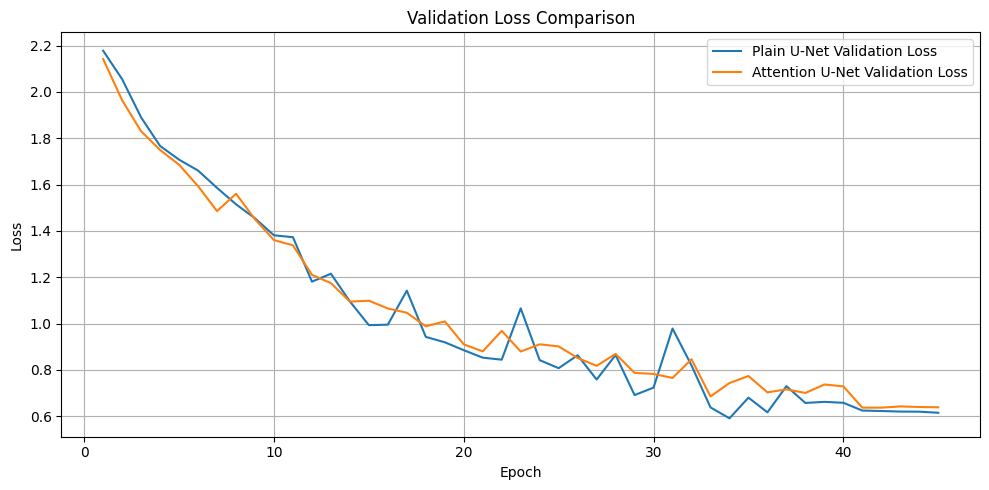

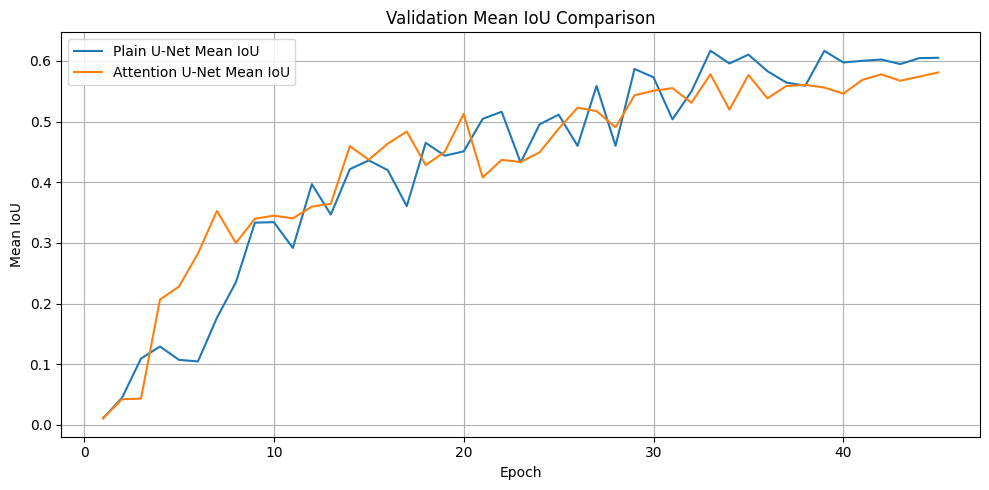

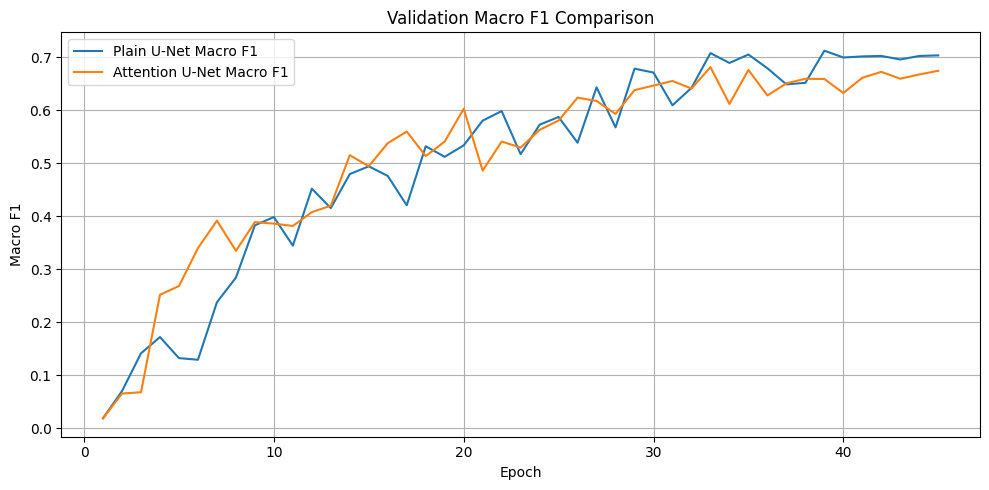

In [30]:
def plot_model_comparison(plain_history, attention_history):
    plain_epochs = range(1, len(plain_history["val_loss"]) + 1)
    attention_epochs = range(1, len(attention_history["val_loss"]) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(
        plain_epochs,
        plain_history["val_loss"],
        label="Plain U-Net Validation Loss"
    )
    plt.plot(
        attention_epochs,
        attention_history["val_loss"],
        label="Attention U-Net Validation Loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(
        plain_epochs,
        plain_history["mean_iou"],
        label="Plain U-Net Mean IoU"
    )
    plt.plot(
        attention_epochs,
        attention_history["mean_iou"],
        label="Attention U-Net Mean IoU"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Mean IoU")
    plt.title("Validation Mean IoU Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(
        plain_epochs,
        plain_history["macro_f1"],
        label="Plain U-Net Macro F1"
    )
    plt.plot(
        attention_epochs,
        attention_history["macro_f1"],
        label="Attention U-Net Macro F1"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title("Validation Macro F1 Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_model_comparison(
    plain_history,
    attention_history
)

In [15]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        hidden_channels = max(
            channels // reduction,
            1
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, hidden_channels),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_channels, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size, channels, _, _ = x.shape

        weights = self.pool(x).view(
            batch_size,
            channels
        )

        weights = self.fc(weights)

        weights = weights.view(
            batch_size,
            channels,
            1,
            1
        )

        return x * weights

In [16]:
class AttentionGate(nn.Module):
    def __init__(
        self,
        gate_channels,
        skip_channels,
        inter_channels
    ):
        super().__init__()

        self.gate_conv = nn.Conv2d(
            gate_channels,
            inter_channels,
            kernel_size=1
        )

        self.skip_conv = nn.Conv2d(
            skip_channels,
            inter_channels,
            kernel_size=1
        )

        self.attention = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(
                inter_channels,
                1,
                kernel_size=1
            ),
            nn.Sigmoid()
        )

    def forward(self, gate, skip):
        gate_features = self.gate_conv(gate)
        skip_features = self.skip_conv(skip)

        attention_weights = self.attention(
            gate_features + skip_features
        )

        return skip * attention_weights


class AttentionUpBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionGate(
            gate_channels=out_channels,
            skip_channels=skip_channels,
            inter_channels=max(
                out_channels // 2,
                1
            )
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)

        skip = self.attention(
            gate=x,
            skip=skip
        )

        x = torch.cat([x, skip], dim=1)

        return self.conv(x)

In [17]:
class AttentionUNetSE(nn.Module):
    def __init__(
        self,
        in_channels=NUM_BANDS,
        num_classes=NUM_CLASSES
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        #Encoder
        self.encoder1 = DoubleConv(
            in_channels,
            16
        )
        self.encoder2 = DoubleConv(16, 32)
        self.encoder3 = DoubleConv(32, 64)
        self.encoder4 = DoubleConv(64, 128)

        #Channel-attention blocks
        self.se1 = SEBlock(16)
        self.se2 = SEBlock(32)
        self.se3 = SEBlock(64)
        self.se4 = SEBlock(128)

        #Bottleneck
        self.bottleneck = DoubleConv(
            128,
            256
        )
        self.se_bottleneck = SEBlock(256)

        #Decoder with spatial attention
        self.decoder4 = AttentionUpBlock(
            256,
            128,
            128
        )
        self.decoder3 = AttentionUpBlock(
            128,
            64,
            64
        )
        self.decoder2 = AttentionUpBlock(
            64,
            32,
            32
        )
        self.decoder1 = AttentionUpBlock(
            32,
            16,
            16
        )

        self.output_layer = nn.Conv2d(
            16,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        enc1 = self.se1(
            self.encoder1(x)
        )

        enc2 = self.se2(
            self.encoder2(
                self.pool(enc1)
            )
        )

        enc3 = self.se3(
            self.encoder3(
                self.pool(enc2)
            )
        )

        enc4 = self.se4(
            self.encoder4(
                self.pool(enc3)
            )
        )

        x = self.se_bottleneck(
            self.bottleneck(
                self.pool(enc4)
            )
        )

        x = self.decoder4(x, enc4)
        x = self.decoder3(x, enc3)
        x = self.decoder2(x, enc2)
        x = self.decoder1(x, enc1)

        return self.output_layer(x)

In [18]:
SE_MODEL_PATH = Path("/kaggle/working/marida_attention_unet_se_best.pt")

set_seed(SEED)

se_model = AttentionUNetSE()

if torch.cuda.device_count() > 1:
    se_model = nn.DataParallel(se_model)
    print("Using", torch.cuda.device_count(), "GPUs")

se_model = se_model.to(device)

se_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    ignore_index=IGNORE_INDEX
)

se_optimizer = torch.optim.Adam(
    se_model.parameters(),
    lr=LEARNING_RATE
)

se_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=device.type == "cuda"
)

se_parameter_count = sum(
    parameter.numel()
    for parameter in se_model.parameters()
)

print("Attention U-Net + SE parameters:",f"{se_parameter_count:,}")

Using 2 GPUs
Attention U-Net + SE parameters: 1,986,933


In [35]:
image, mask = datasets["train"][0]

se_model.eval()

with torch.no_grad():
    output = se_model(
        image.unsqueeze(0).to(device)
    )

print("Input shape:", image.unsqueeze(0).shape)
print("Output shape:", output.shape)
print("Mask shape:", mask.shape)
print("Output finite:", torch.isfinite(output).all().item())

del image, mask, output
torch.cuda.empty_cache()

Input shape: torch.Size([1, 11, 256, 256])
Output shape: torch.Size([1, 11, 256, 256])
Mask shape: torch.Size([256, 256])
Output finite: True


In [19]:
se_history = train_model(
    model=se_model,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    optimizer=se_optimizer,
    criterion=se_criterion,
    scaler=se_scaler,
    epochs=NUM_EPOCHS,
    model_path=SE_MODEL_PATH,
    scheduler=None
)


Epoch 1/45
Train Loss: 2.3138
Validation Loss: 2.2077
Mean IoU: 0.0088
Macro F1: 0.0162
Pixel Accuracy: 0.0904
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 2/45
Train Loss: 2.0385
Validation Loss: 2.0782
Mean IoU: 0.0425
Macro F1: 0.0665
Pixel Accuracy: 0.1889
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 3/45
Train Loss: 1.8593
Validation Loss: 1.9491
Mean IoU: 0.0561
Macro F1: 0.0857
Pixel Accuracy: 0.1897
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 4/45
Train Loss: 1.7206
Validation Loss: 1.8662
Mean IoU: 0.1063
Macro F1: 0.1297
Pixel Accuracy: 0.1928
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 5/45
Train Loss: 1.6356
Validation Loss: 1.7753
Mean IoU: 0.1093
Macro F1: 0.1318
Pixel Accuracy: 0.1946
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 6/45
Train Loss: 1.6598
Validation Loss: 1.7077
Mean IoU: 0.1019
Macro F1: 0.1271
Pixel Accuracy: 0.1879
Training Batches: 139 used, 0 skipped
Saved best mode

In [20]:
load_model(se_model,SE_MODEL_PATH)

se_test_results = evaluate_model(se_model,loaders["test"],se_criterion)

print_results(se_test_results)

Test loss: 0.6346
Mean IoU: 0.5373
Macro F1: 0.6396
Pixel accuracy: 0.9376

Per-class results
------------------------------------------------------------------------------------------
 0 Marine Debris                IoU: 0.0828  Precision: 0.0857  Recall: 0.7139  F1: 0.1530
 1 Dense Sargassum              IoU: 0.6488  Precision: 0.6545  Recall: 0.9868  F1: 0.7870
 2 Sparse Sargassum             IoU: 0.4582  Precision: 0.7166  Recall: 0.5596  F1: 0.6284
 3 Natural Organic Material     IoU: 0.1053  Precision: 0.2286  Recall: 0.1633  F1: 0.1905
 4 Ship                         IoU: 0.5613  Precision: 0.6537  Recall: 0.7990  F1: 0.7190
 5 Clouds                       IoU: 0.9083  Precision: 0.9788  Recall: 0.9265  F1: 0.9519
 6 Marine Water                 IoU: 0.7619  Precision: 0.9072  Recall: 0.8263  F1: 0.8649
 7 Sediment-Laden Water         IoU: 0.9889  Precision: 0.9985  Recall: 0.9904  F1: 0.9944
 8 Foam                         IoU: 0.2116  Precision: 0.2318  Recall: 0.7080  F1: 0.3

In [21]:
class AttentionUNetDeepSE(nn.Module):
    def __init__(
        self,
        in_channels=NUM_BANDS,
        num_classes=NUM_CLASSES
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        #Encoder
        self.encoder1 = DoubleConv(
            in_channels,
            16
        )

        self.encoder2 = DoubleConv(
            16,
            32
        )

        self.encoder3 = DoubleConv(
            32,
            64
        )

        self.encoder4 = DoubleConv(
            64,
            128
        )

        #SE is applied only to deeper feature maps
        self.se3 = SEBlock(64)
        self.se4 = SEBlock(128)

        # Bottleneck
        self.bottleneck = DoubleConv(
            128,
            256
        )

        self.se_bottleneck = SEBlock(256)

        #Decoder with spatial attention
        self.decoder4 = AttentionUpBlock(
            in_channels=256,
            skip_channels=128,
            out_channels=128
        )

        self.decoder3 = AttentionUpBlock(
            in_channels=128,
            skip_channels=64,
            out_channels=64
        )

        self.decoder2 = AttentionUpBlock(
            in_channels=64,
            skip_channels=32,
            out_channels=32
        )

        self.decoder1 = AttentionUpBlock(
            in_channels=32,
            skip_channels=16,
            out_channels=16
        )

        self.output_layer = nn.Conv2d(
            16,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        #No SE in the early layers
        enc1 = self.encoder1(x)

        enc2 = self.encoder2(
            self.pool(enc1)
        )

        #SE begins at the deeper encoder levels
        enc3 = self.encoder3(
            self.pool(enc2)
        )
        enc3 = self.se3(enc3)

        enc4 = self.encoder4(
            self.pool(enc3)
        )
        enc4 = self.se4(enc4)

        x = self.bottleneck(
            self.pool(enc4)
        )
        x = self.se_bottleneck(x)

        x = self.decoder4(x, enc4)
        x = self.decoder3(x, enc3)
        x = self.decoder2(x, enc2)
        x = self.decoder1(x, enc1)

        return self.output_layer(x)

In [22]:
DEEP_SE_MODEL_PATH = Path(
    "/kaggle/working/"
    "marida_attention_unet_deep_se_best.pt"
)

set_seed(SEED)

deep_se_model = AttentionUNetDeepSE()

if torch.cuda.device_count() > 1:
    deep_se_model = nn.DataParallel(
        deep_se_model
    )

    print(
        "Using",
        torch.cuda.device_count(),
        "GPUs"
    )

deep_se_model = deep_se_model.to(device)

deep_se_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    ignore_index=IGNORE_INDEX
)

deep_se_optimizer = torch.optim.Adam(
    deep_se_model.parameters(),
    lr=LEARNING_RATE
)

deep_se_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=device.type == "cuda"
)

deep_se_parameter_count = sum(
    parameter.numel()
    for parameter in deep_se_model.parameters()
)

print(
    "Attention U-Net + Deep SE parameters:",
    f"{deep_se_parameter_count:,}"
)

Using 2 GPUs
Attention U-Net + Deep SE parameters: 1,986,559


In [ ]:
image, mask = datasets["train"][0]

deep_se_model.eval()

with torch.no_grad():
    output = deep_se_model(
        image.unsqueeze(0).to(device)
    )

print("Input shape:",image.unsqueeze(0).shape)

print("Output shape:",output.shape)

print("Mask shape:", mask.shape)

print("Finite output:",torch.isfinite(output).all().item())

del image, mask, output
torch.cuda.empty_cache()

In [23]:
deep_se_history = train_model(
    model=deep_se_model,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    optimizer=deep_se_optimizer,
    criterion=deep_se_criterion,
    scaler=deep_se_scaler,
    epochs=45,
    model_path=DEEP_SE_MODEL_PATH,
    scheduler=None
)


Epoch 1/45
Train Loss: 2.3293
Validation Loss: 2.1499
Mean IoU: 0.0450
Macro F1: 0.0709
Pixel Accuracy: 0.1868
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 2/45
Train Loss: 2.0341
Validation Loss: 2.0027
Mean IoU: 0.0391
Macro F1: 0.0614
Pixel Accuracy: 0.1786
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 3/45
Train Loss: 1.9099
Validation Loss: 1.9111
Mean IoU: 0.0416
Macro F1: 0.0649
Pixel Accuracy: 0.1882
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 4/45
Train Loss: 1.8375
Validation Loss: 1.9001
Mean IoU: 0.0427
Macro F1: 0.0669
Pixel Accuracy: 0.1896
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 5/45
Train Loss: 1.7712
Validation Loss: 1.8564
Mean IoU: 0.0434
Macro F1: 0.0677
Pixel Accuracy: 0.1893
Training Batches: 139 used, 0 skipped
Saved best model

Epoch 6/45
Train Loss: 1.7325
Validation Loss: 1.8235
Mean IoU: 0.0548
Macro F1: 0.0864
Pixel Accuracy: 0.1908
Training Batches: 139 used, 0 skipped
Saved best mode

In [24]:
load_model(deep_se_model,DEEP_SE_MODEL_PATH)

deep_se_test_results = evaluate_model(model=deep_se_model,loader=loaders["test"],criterion=deep_se_criterion)

print_results(deep_se_test_results)

Test loss: 0.6107
Mean IoU: 0.5913
Macro F1: 0.7075
Pixel accuracy: 0.9206

Per-class results
------------------------------------------------------------------------------------------
 0 Marine Debris                IoU: 0.1839  Precision: 0.2272  Recall: 0.4908  F1: 0.3106
 1 Dense Sargassum              IoU: 0.6715  Precision: 0.6826  Recall: 0.9763  F1: 0.8035
 2 Sparse Sargassum             IoU: 0.5390  Precision: 0.8191  Recall: 0.6118  F1: 0.7005
 3 Natural Organic Material     IoU: 0.2564  Precision: 0.4082  Recall: 0.4082  F1: 0.4082
 4 Ship                         IoU: 0.3398  Precision: 0.3586  Recall: 0.8663  F1: 0.5072
 5 Clouds                       IoU: 0.7291  Precision: 0.9910  Recall: 0.7339  F1: 0.8433
 6 Marine Water                 IoU: 0.7065  Precision: 0.7721  Recall: 0.8926  F1: 0.8280
 7 Sediment-Laden Water         IoU: 0.9988  Precision: 0.9991  Recall: 0.9997  F1: 0.9994
 8 Foam                         IoU: 0.8355  Precision: 0.8467  Recall: 0.9845  F1: 0.9

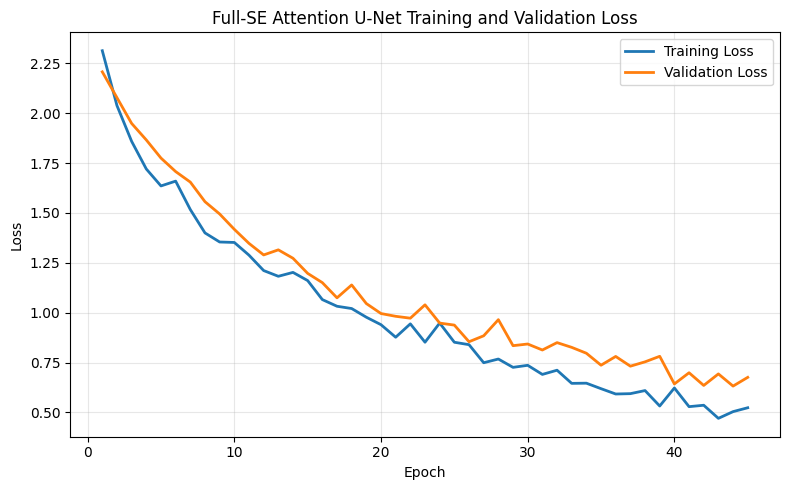

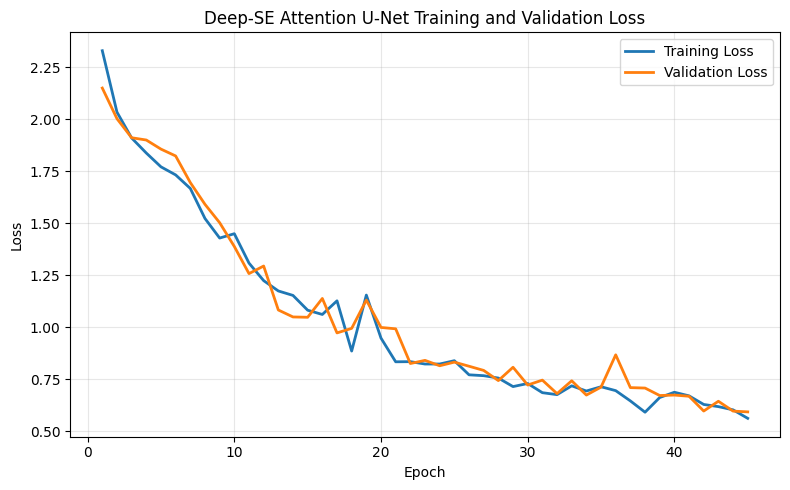

In [27]:
import matplotlib.pyplot as plt


#Full-SE Attention U-Net
epochs = range(1, len(se_history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    se_history["train_loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    epochs,
    se_history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Full-SE Attention U-Net Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#Deep-SE Attention U-Net
epochs = range(1, len(deep_se_history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    deep_se_history["train_loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    epochs,
    deep_se_history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Deep-SE Attention U-Net Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()